c:\Users\cheng\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Data shape: (100000, 14)
Training set size: 80000
Testing set size: 20000

=== Training Base Prophet Model ===


02:45:11 - cmdstanpy - INFO - Chain [1] start processing
02:45:28 - cmdstanpy - INFO - Chain [1] done processing


Base Prophet model training time: 21.03 seconds
--- Base Prophet Model Performance Metrics ---
RMSE: 0.66
R² Score: 0.5672
MAPE: 85.07%
Prediction Accuracy: 14.93%


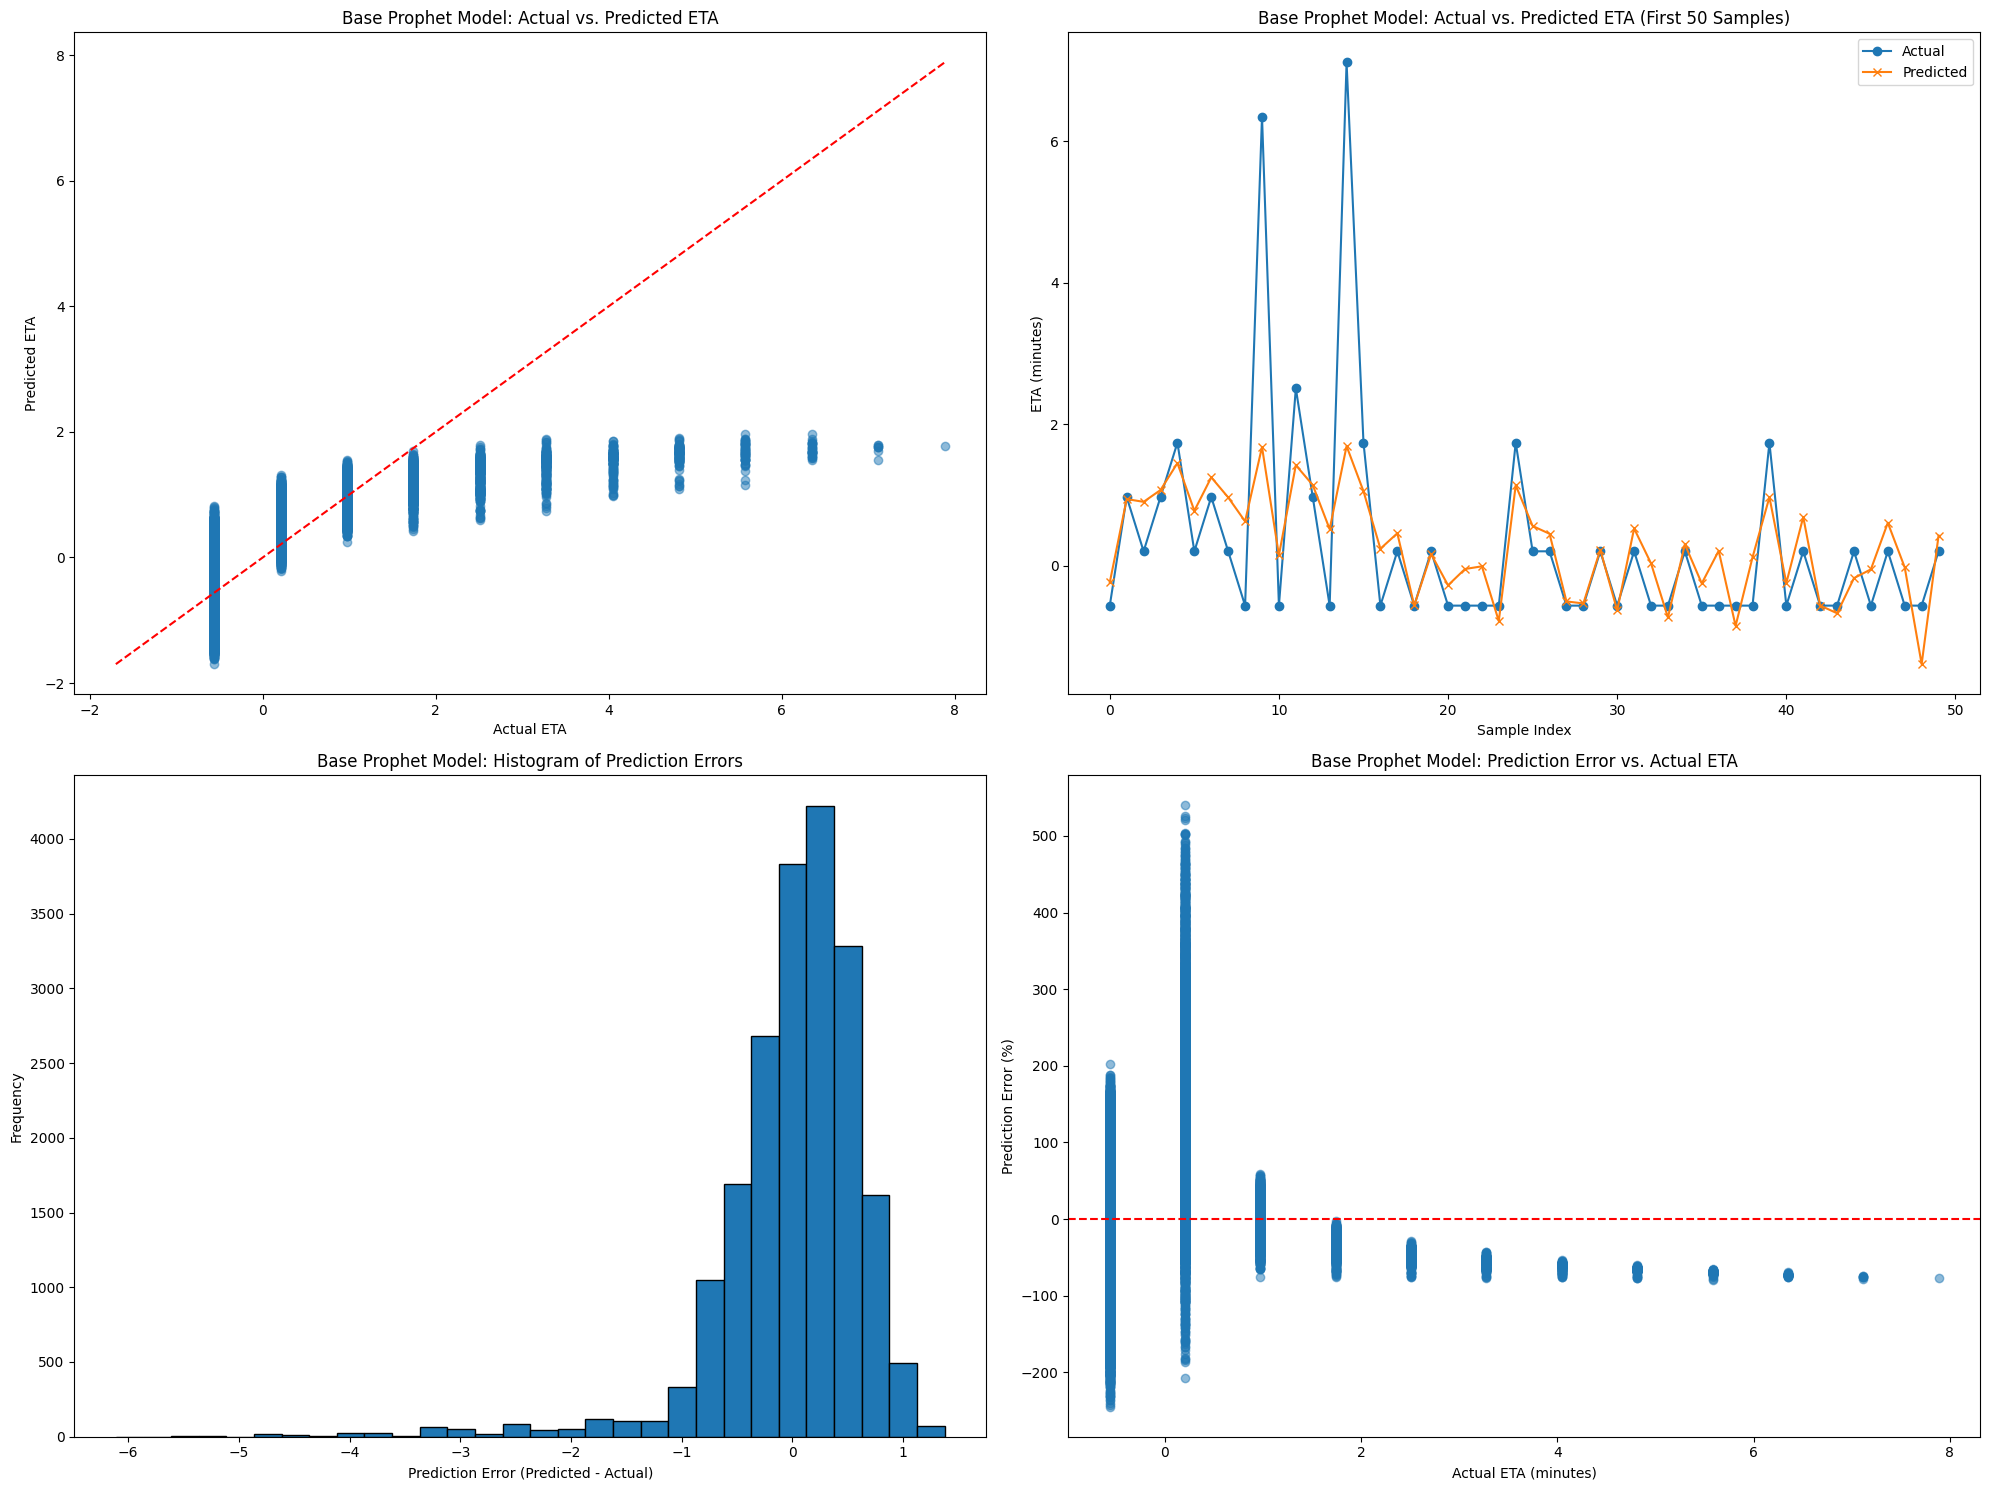

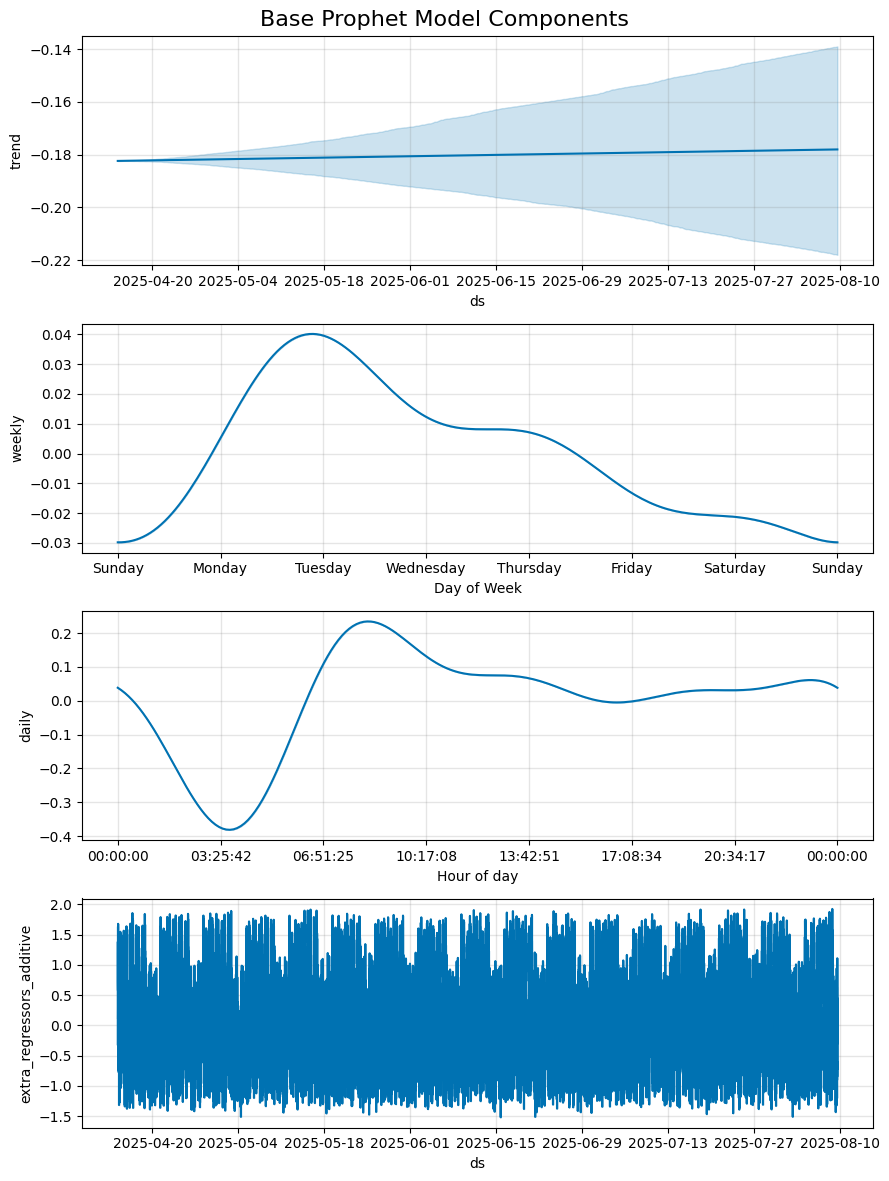

Plotly visualization failed: Mime type rendering requires nbformat>=4.2.0 but it is not installed
You can install plotly with: pip install plotly

=== Training Optimized Prophet Model ===


TypeError: ufunc 'invert' not supported for the input types, and the inputs could not be safely coerced to any supported types according to the casting rule ''safe''

: 

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
from sklearn.metrics import mean_squared_error, r2_score
from prophet import Prophet
from prophet.plot import plot_components_plotly, plot_plotly
import plotly.offline as py

# Load dataset
df = pd.read_csv('bus_eta_standard_scaled.csv')
print("Data shape:", df.shape)

# Convert timestamp to datetime if it's not already
if not pd.api.types.is_datetime64_any_dtype(df['timestamp']):
    df['timestamp'] = pd.to_datetime(df['timestamp'])

# Function to evaluate model performance (similar to previous implementations)
def evaluate_model(y_test, y_pred, model_name):
    # Calculate metrics
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    # Handle zero values in y_test for MAPE calculation
    mask = y_test != 0
    if mask.any():
        mape = np.mean(np.abs((y_test[mask] - y_pred[mask]) / y_test[mask])) * 100
    else:
        mape = np.nan
    accuracy = 100 - mape if not np.isnan(mape) else np.nan
    
    print(f"--- {model_name} Performance Metrics ---")
    print(f'RMSE: {rmse:.2f}')
    print(f'R² Score: {r2:.4f}')
    if not np.isnan(mape):
        print(f"MAPE: {mape:.2f}%")
        print(f"Prediction Accuracy: {accuracy:.2f}%")
    else:
        print("MAPE: Cannot calculate (division by zero)")
        print("Prediction Accuracy: Cannot calculate")
    
    # Create visualizations
    fig, axes = plt.subplots(2, 2, figsize=(20, 15))
    
    # Scatter plot of actual vs predicted
    axes[0, 0].scatter(y_test, y_pred, alpha=0.5)
    axes[0, 0].plot([min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())], 
                    [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())], 
                    'r', linestyle='--')
    axes[0, 0].set_xlabel("Actual ETA")
    axes[0, 0].set_ylabel("Predicted ETA")
    axes[0, 0].set_title(f"{model_name}: Actual vs. Predicted ETA")
    
    # Line plot of first 50 samples
    sample_indices = np.arange(min(50, len(y_test)))
    axes[0, 1].plot(sample_indices, y_test.iloc[sample_indices] if hasattr(y_test, 'iloc') else y_test[sample_indices], 
                   label="Actual", marker='o')
    axes[0, 1].plot(sample_indices, y_pred[sample_indices], label="Predicted", marker='x')
    axes[0, 1].set_xlabel("Sample Index")
    axes[0, 1].set_ylabel("ETA (minutes)")
    axes[0, 1].set_title(f"{model_name}: Actual vs. Predicted ETA (First {len(sample_indices)} Samples)")
    axes[0, 1].legend()
    
    # Histogram of errors
    errors = y_pred - y_test
    axes[1, 0].hist(errors, bins=30, edgecolor='black')
    axes[1, 0].set_xlabel("Prediction Error (Predicted - Actual)")
    axes[1, 0].set_ylabel("Frequency")
    axes[1, 0].set_title(f"{model_name}: Histogram of Prediction Errors")
    
    # Percentage error vs actual (handling zero values)
    if mask.any():
        percentage_error = 100 * (y_pred[mask] - y_test[mask]) / y_test[mask]
        axes[1, 1].scatter(y_test[mask], percentage_error, alpha=0.5)
        axes[1, 1].axhline(y=0, color='r', linestyle='--')
        axes[1, 1].set_xlabel("Actual ETA (minutes)")
        axes[1, 1].set_ylabel("Prediction Error (%)")
        axes[1, 1].set_title(f"{model_name}: Prediction Error vs. Actual ETA")
    else:
        axes[1, 1].text(0.5, 0.5, "Cannot calculate percentage error (division by zero)", 
                       ha='center', va='center', transform=axes[1, 1].transAxes)
    
    plt.tight_layout()
    plt.show()
    
    return {
        'rmse': rmse,
        'r2': r2,
        'mape': mape if not np.isnan(mape) else None,
        'accuracy': accuracy if not np.isnan(accuracy) else None,
        'predictions': y_pred
    }

# Prepare data for Prophet
def prepare_data_for_prophet(df, target_col='eta_minutes', time_col='timestamp'):
    """
    Prepare dataframe for Prophet by renaming columns and selecting necessary ones.
    For Prophet, we need 'ds' (datestamp) and 'y' (target) columns.
    """
    prophet_df = df[[time_col, target_col]].copy()
    prophet_df.rename(columns={time_col: 'ds', target_col: 'y'}, inplace=True)
    return prophet_df

# Split data into train and test
def train_test_split_by_time(df, test_size=0.2):
    """Split the data by time, keeping the most recent observations for testing."""
    df = df.sort_values('timestamp')
    split_idx = int(len(df) * (1 - test_size))
    train = df.iloc[:split_idx].copy()
    test = df.iloc[split_idx:].copy()
    return train, test

# Prepare the relevant regressor columns (features)
def extract_regressors(df):
    """Extract features to use as regressors in Prophet model."""
    regressor_cols = ['stop_sequence', 'current_stop_name', 'next_stop_name', 
                      'day_of_week', 'is_holiday', 'is_peak_hour', 
                      'weather_condition', 'passenger_count', 'current_speed',
                      'distance_to_next_stop', 'current_lat', 'current_lon']
    
    regressor_df = df[regressor_cols].copy()
    return regressor_cols, regressor_df

# Train test split
train_df, test_df = train_test_split_by_time(df, test_size=0.2)
print(f"Training set size: {len(train_df)}")
print(f"Testing set size: {len(test_df)}")

# Get regressor columns
regressor_cols, _ = extract_regressors(df)

# Prepare data for Prophet
train_prophet = prepare_data_for_prophet(train_df)
test_prophet = prepare_data_for_prophet(test_df)

print("\n=== Training Base Prophet Model ===")
start_time = time.time()

# Create and fit the basic Prophet model
base_model = Prophet(
    interval_width=0.95,
    daily_seasonality=True,
    weekly_seasonality=True,
    yearly_seasonality=False,
    seasonality_mode='additive'
)

# Add regressors
for col in regressor_cols:
    if col in train_df.columns:
        base_model.add_regressor(col)

# Fit the model
base_model.fit(train_prophet.join(train_df[regressor_cols]))
base_training_time = time.time() - start_time
print(f"Base Prophet model training time: {base_training_time:.2f} seconds")

# Make predictions
future = test_prophet[['ds']].join(test_df[regressor_cols])
forecast = base_model.predict(future)

# Extract predictions for evaluation
y_test = test_prophet['y']
y_pred = forecast['yhat'].values

# Evaluate the base model
base_results = evaluate_model(y_test, y_pred, "Base Prophet Model")

# Plot forecast components
fig1 = base_model.plot_components(forecast)
plt.suptitle('Base Prophet Model Components', fontsize=16)
plt.tight_layout()
plt.show()

# Try to use plotly if available for interactive plots
try:
    # Plot components using plotly
    fig2 = plot_components_plotly(base_model, forecast)
    py.iplot(fig2)
    
    # Plot forecast using plotly
    fig3 = plot_plotly(base_model, forecast)
    py.iplot(fig3)
except Exception as e:
    print(f"Plotly visualization failed: {e}")
    print("You can install plotly with: pip install plotly")

print("\n=== Training Optimized Prophet Model ===")

# Optimized model with additional parameters and changepoints
start_time = time.time()
optimized_model = Prophet(
    interval_width=0.95,
    daily_seasonality=True,
    weekly_seasonality=True,
    yearly_seasonality=False,
    seasonality_mode='multiplicative',  # Try multiplicative instead of additive
    changepoint_prior_scale=0.05,       # Flexibility of the trend
    seasonality_prior_scale=10.0,       # Flexibility of the seasonality
    n_changepoints=25                   # Number of potential changepoints
)

# Add custom seasonalities if there are patterns specific to bus schedules
optimized_model.add_seasonality(
    name='hourly', 
    period=24/24,  # Every hour
    fourier_order=5
)

# Add additional seasonality for peak hours
optimized_model.add_seasonality(
    name='peak_hours',
    period=24,
    fourier_order=5,
    condition_name='is_peak_hour'
)

# Add regressors with specified mode (how they interact with the forecast)
for col in regressor_cols:
    if col in train_df.columns:
        # You can specify mode='multiplicative' for regressors that scale the forecast
        # or mode='additive' for regressors that shift the forecast
        mode = 'multiplicative' if col in ['passenger_count', 'current_speed'] else 'additive'
        optimized_model.add_regressor(col, mode=mode)

# Create a copy of the training data with a condition column for peak hours
train_data_with_conditions = train_prophet.join(train_df[regressor_cols])
train_data_with_conditions['is_peak_hour'] = train_df['is_peak_hour'].astype(bool)

# Fit the optimized model
optimized_model.fit(train_data_with_conditions)
optimized_training_time = time.time() - start_time
print(f"Optimized Prophet model training time: {optimized_training_time:.2f} seconds")

# Create test data with conditions
test_data_with_conditions = test_prophet[['ds']].join(test_df[regressor_cols])
test_data_with_conditions['is_peak_hour'] = test_df['is_peak_hour'].astype(bool)

# Make predictions
optimized_forecast = optimized_model.predict(test_data_with_conditions)

# Extract predictions for evaluation
y_pred_optimized = optimized_forecast['yhat'].values

# Evaluate the optimized model
optimized_results = evaluate_model(y_test, y_pred_optimized, "Optimized Prophet Model")

# Plot forecast components for optimized model
fig4 = optimized_model.plot_components(optimized_forecast)
plt.suptitle('Optimized Prophet Model Components', fontsize=16)
plt.tight_layout()
plt.show()

# Compare the performance of base and optimized models
print("\n=== Performance Comparison ===")
print(f"{'Metric':<20} {'Base Model':<15} {'Optimized Model':<15} {'Improvement':<15}")
print("-" * 65)

# Helper function to calculate improvement
def calc_improvement(base, optimized, higher_is_better=False):
    if base is None or optimized is None:
        return "N/A"
    if higher_is_better:
        improvement = (optimized - base) / abs(base) * 100
    else:
        improvement = (base - optimized) / abs(base) * 100
    return f"{improvement:.2f}%"

metrics = [
    ('RMSE', base_results['rmse'], optimized_results['rmse'], False),
    ('R² Score', base_results['r2'], optimized_results['r2'], True),
    ('MAPE', base_results['mape'], optimized_results['mape'], False),
    ('Accuracy', base_results['accuracy'], optimized_results['accuracy'], True),
    ('Training Time (s)', base_training_time, optimized_training_time, False)
]

for metric, base, optimized, higher_is_better in metrics:
    base_value = f"{base:.4f}" if base is not None else "N/A"
    optimized_value = f"{optimized:.4f}" if optimized is not None else "N/A"
    improvement = calc_improvement(base, optimized, higher_is_better) if base is not None and optimized is not None else "N/A"
    print(f"{metric:<20} {base_value:<15} {optimized_value:<15} {improvement:<15}")

# Cross-validation with Prophet (optional, can take time)
print("\n=== Performing Cross-Validation on Prophet Model (Optional) ===")
try:
    from prophet.diagnostics import cross_validation, performance_metrics
    
    # Perform cross-validation
    df_cv = cross_validation(
        optimized_model, 
        initial='80%',             # Use 80% of data for initial training
        period='24h',              # Each cutoff is 24 hours apart
        horizon='48h',             # Forecast 48 hours
        parallel='processes'       # Use parallel processing
    )
    
    # Calculate performance metrics
    df_p = performance_metrics(df_cv)
    print("Cross-validation metrics:")
    print(df_p.head())
    
    # Plot metrics
    from prophet.plot import plot_cross_validation_metric
    fig5 = plot_cross_validation_metric(df_cv, metric='rmse')
    plt.title('Cross-Validation RMSE')
    plt.show()
    
    fig6 = plot_cross_validation_metric(df_cv, metric='mape')
    plt.title('Cross-Validation MAPE')
    plt.show()
    
except ImportError:
    print("Prophet diagnostics not imported. Skipping cross-validation.")
except Exception as e:
    print(f"Cross-validation failed: {e}")

# Save the optimized model
import pickle
with open('prophet_optimized_model.pkl', 'wb') as f:
    pickle.dump(optimized_model, f)
print("Optimized Prophet model saved as 'prophet_optimized_model.pkl'")

# Create a unified comparison between all models (placeholder)
print("\n=== All Models Comparison ===")
print("Note: Run all model scripts and fill in the actual values")
print(f"{'Metric':<20} {'Prophet':<15} {'XGBoost':<15} {'LightGBM':<15} {'Neural Network':<15}")
print("-" * 85)